# Unsupervised Learning Practice Solution

## Clustering student lifestyle patterns in 2D

This solution notebook demonstrates how to apply:

- **K-Means**
- **DBSCAN**
- **Agglomerative (Hierarchical) Clustering**

to a simple two-dimensional dataset describing student weekly habits:

- **StudyHours**
- **SocialHours**

## 1. Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(42)

## 2. Create the 2D dataset

In [2]:
n1, n2, n3 = 45, 45, 45

g1_study  = np.random.normal(loc=22, scale=3.0, size=n1)
g1_social = np.random.normal(loc=6,  scale=1.8, size=n1)

g2_study  = np.random.normal(loc=14, scale=2.5, size=n2)
g2_social = np.random.normal(loc=12, scale=2.3, size=n2)

g3_study  = np.random.normal(loc=7,  scale=2.0, size=n3)
g3_social = np.random.normal(loc=19, scale=2.8, size=n3)

out_study  = np.array([3, 28, 26, 1, 30, 10])
out_social = np.array([2, 24, 3, 26, 1, 28])

study_hours = np.concatenate([g1_study, g2_study, g3_study, out_study])
social_hours = np.concatenate([g1_social, g2_social, g3_social, out_social])

df = pd.DataFrame({
    "StudyHours": np.clip(study_hours, 0, None),
    "SocialHours": np.clip(social_hours, 0, None)
})

df.head()

,StudyHours,SocialHours
0,23.490142,4.704280
1,21.585207,5.170850
2,23.943066,7.902820
3,26.569090,6.618513
4,21.297540,2.826528


In [3]:
display(df.describe().round(2))

,StudyHours,SocialHours
count,141.00,141.00
mean,14.21,12.46
std,6.67,6.14
min,1.00,1.00
25%,8.25,7.10
50%,13.93,12.58
75%,20.19,17.02
max,30.00,28.00


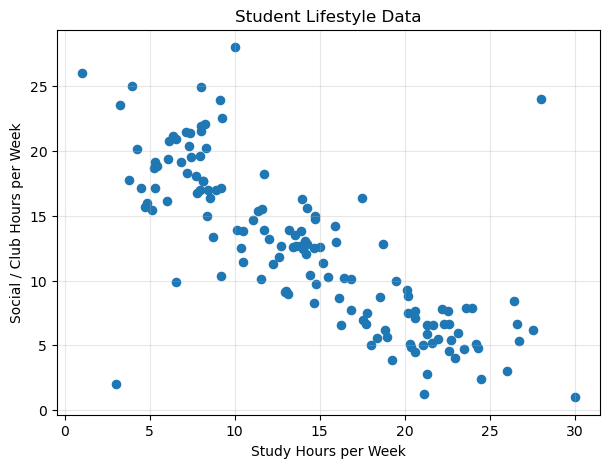

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df["StudyHours"], df["SocialHours"], s=35)
plt.xlabel("Study Hours per Week")
plt.ylabel("Social / Club Hours per Week")
plt.title("Student Lifestyle Data")
plt.grid(alpha=0.3)
plt.show()

### Observation

The scatter plot suggests roughly three main behavior regions:

1. a group with high study hours and lower social hours,
2. a middle balanced group,
3. a group with lower study hours and higher social hours.

A few points appear unusual and may behave like outliers.

## 3. Standardize the features

In [5]:
X = df[["StudyHours", "SocialHours"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.39631757, -1.26680262],
       [ 1.10976781, -1.19057271],
       [ 1.4644485 , -0.74421329],
       [ 1.85946796, -0.95404817],
       [ 1.06649549, -1.57359687]])

## 4. K-Means clustering

In [6]:
ks = range(2, 7)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}, inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.3f}")

k=2, inertia=105.31, silhouette=0.509
k=3, inertia=53.64, silhouette=0.540
k=4, inertia=46.85, silhouette=0.442
k=5, inertia=38.53, silhouette=0.450
k=6, inertia=32.68, silhouette=0.378


c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packag

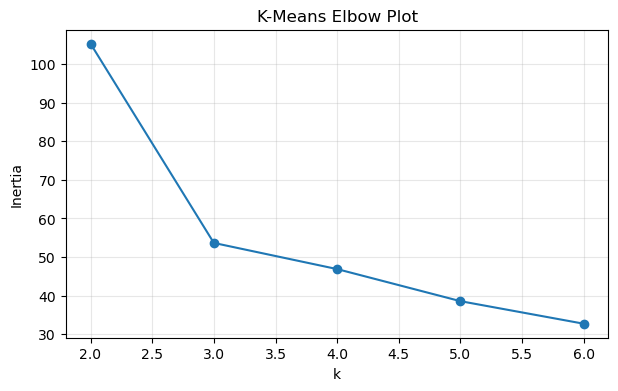

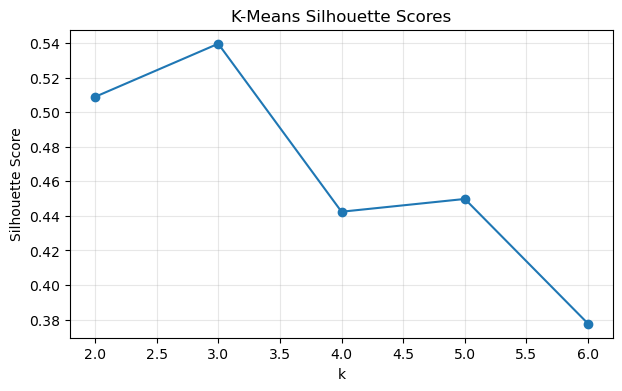

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Plot")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(list(ks), sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.grid(alpha=0.3)
plt.show()

In [8]:
k_final = list(ks)[int(np.argmax(sil_scores))]
print("Chosen k:", k_final)

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans["KMeansCluster"] = kmeans_labels
display(df_kmeans.head())

Chosen k: 3


c:\Users\willi\anaconda3\envs\william-ml-3-12-12\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,StudyHours,SocialHours,KMeansCluster
0,23.490142,4.704280,2
1,21.585207,5.170850,2
2,23.943066,7.902820,2
3,26.569090,6.618513,2
4,21.297540,2.826528,2


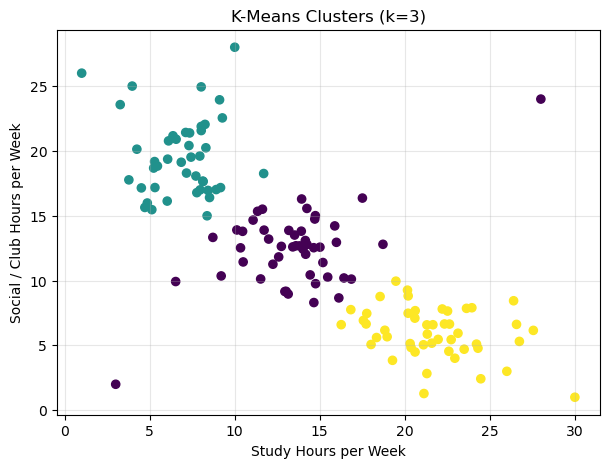

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["StudyHours"],
    df["SocialHours"],
    c=kmeans_labels,
    s=35
)
plt.xlabel("Study Hours per Week")
plt.ylabel("Social / Club Hours per Week")
plt.title(f"K-Means Clusters (k={k_final})")
plt.grid(alpha=0.3)
plt.show()

In [10]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=["StudyHours", "SocialHours"])
display(centers_df.round(2))

profile_kmeans = df.assign(KMeansCluster=kmeans_labels).groupby("KMeansCluster").mean().round(2)
display(profile_kmeans)

,StudyHours,SocialHours
0,13.47,12.42
1,6.88,19.59
2,21.67,5.96


,StudyHours,SocialHours
KMeansCluster,,
0,13.47,12.42
1,6.88,19.59
2,21.67,5.96


### K-Means interpretation

A reasonable choice is **k = 3**, which fits the visible structure of the data well.

The clusters can be interpreted as:

- **high study / lower social**,
- **balanced**,
- **lower study / higher social**.

K-Means works well when the groups are compact and roughly rounded.  
However, it **forces every point into some cluster**, so unusual observations are not explicitly labeled as noise.

## 5. DBSCAN clustering

In [11]:
dbscan = DBSCAN(eps=0.35, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print("Unique DBSCAN labels:", np.unique(db_labels))
print("Noise points:", np.sum(db_labels == -1))

Unique DBSCAN labels: [-1  0]
Noise points: 17


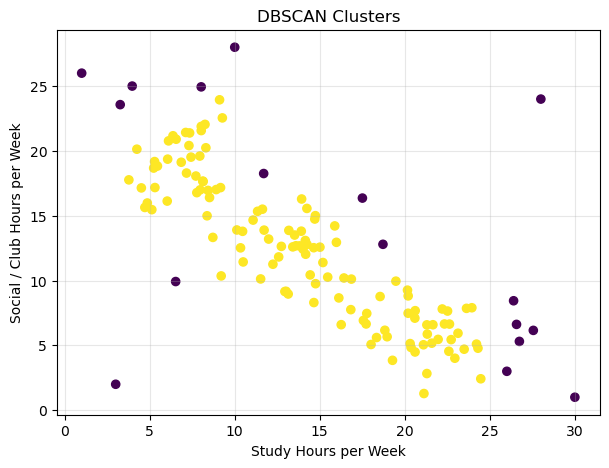

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["StudyHours"],
    df["SocialHours"],
    c=db_labels,
    s=35
)
plt.xlabel("Study Hours per Week")
plt.ylabel("Social / Club Hours per Week")
plt.title("DBSCAN Clusters")
plt.grid(alpha=0.3)
plt.show()

In [13]:
pd.Series(db_labels).value_counts().sort_index()

-1     17
 0    124
Name: count, dtype: int64

### DBSCAN interpretation

DBSCAN can identify dense groups without requiring the number of clusters in advance.

Its key advantage here is that it can label some observations as **noise** using label `-1`.  
That makes DBSCAN especially useful when the dataset contains possible outliers or irregular points.

Compared with K-Means, DBSCAN is often better at handling unusual observations, but it is also more sensitive to parameter choice, especially `eps`.

## 6. Agglomerative clustering

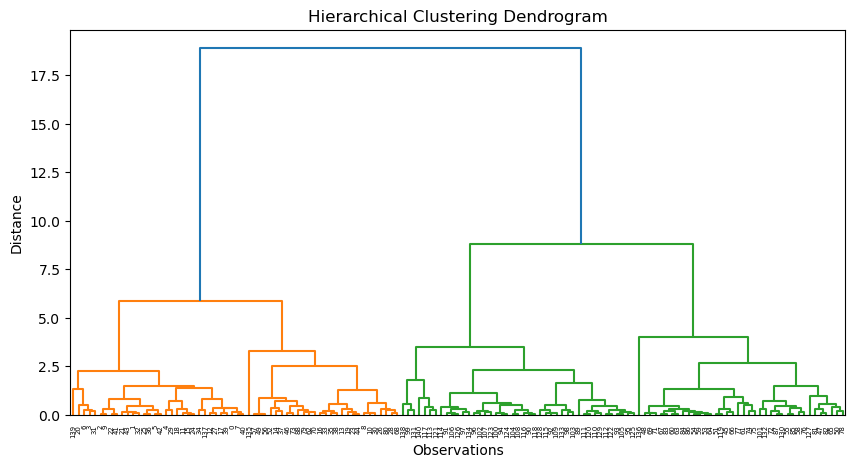

In [14]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

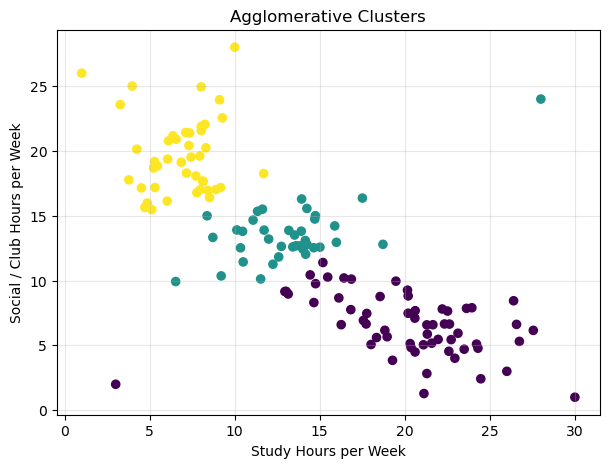

In [15]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    df["StudyHours"],
    df["SocialHours"],
    c=agg_labels,
    s=35
)
plt.xlabel("Study Hours per Week")
plt.ylabel("Social / Club Hours per Week")
plt.title("Agglomerative Clusters")
plt.grid(alpha=0.3)
plt.show()

In [16]:
profile_agg = df.assign(AggCluster=agg_labels).groupby("AggCluster").mean().round(2)
display(profile_agg)

,StudyHours,SocialHours
AggCluster,,
0,20.11,6.57
1,13.22,13.56
2,6.85,19.69


### Agglomerative interpretation

The dendrogram helps us see how clusters merge as the distance threshold increases.

For this dataset, **3 clusters** is also a sensible choice.  
Agglomerative clustering gives a result similar to K-Means because the groups are fairly well separated.

Unlike DBSCAN, Agglomerative clustering still assigns each point to a cluster.

## 7. Compare the methods

In [17]:
comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Agglomerative"],
    "Needs number of clusters in advance?": ["Yes", "No", "Yes"],
    "Can label noise/outliers?": ["No", "Yes", "No"],
    "Works well for compact groups?": ["Yes", "Sometimes", "Yes"],
    "Sensitive to parameter choice?": ["Moderate", "High", "Moderate"]
})

comparison

,Method,Needs number of clusters in advance?,Can label noise/outliers?,Works well for compact groups?,Sensitive to parameter choice?
0,K-Means,Yes,No,Yes,Moderate
1,DBSCAN,No,Yes,Sometimes,High
2,Agglomerative,Yes,No,Yes,Moderate


## Final reflection

For this particular dataset:

- **K-Means** is easy to explain and performs well because the groups are fairly compact.
- **DBSCAN** is valuable because it can identify unusual points as noise.
- **Agglomerative clustering** is useful when we want a hierarchical view through the dendrogram.

### Recommended conclusion

If the goal is **simple student-friendly interpretation**, K-Means is often the easiest starting point.

If the goal is **outlier awareness**, DBSCAN is especially helpful.

If the goal is **understanding how clusters merge step by step**, Agglomerative clustering provides the most informative visual structure.

## Optional extension ideas

You can strengthen this activity further by asking students to:

- change the amount of overlap between groups,
- add more unusual points,
- compare standardized vs non-standardized data,
- or test whether the same conclusions hold with a third feature.